In [ ]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from einops import rearrange
from mpl_toolkits.mplot3d import Axes3D
import random
import torchvision.transforms as T
from PIL import Image
import cv2

Download the MNIST dataset using the torchvision library and create a subset of the dataset containing 1,000 samples. Each sample will include a 28 × 28 pixel image, along with a single integer value denoting the sample’s respective class (number)

In [ ]:
transform = transforms.ToTensor()
mnistDataset = torchvision.datasets.MNIST(root = './data', train = True, download = True, transform = transform)
# this is where i loaded the MNIST dataset. the images are converted automatically to tensors.

Create a subset of 1000 samples.

In [ ]:
subsetIndices = torch.randperm(len(mnistDataset))[:1000]
mnistSubset = torch.utils.data.Subset(mnistDataset, subsetIndices)
# in this portion, it randomly selects 1000 samples from the dataset so we can create a smaller subset.

Now we are going to extract images and labels.

In [ ]:
images = torch.stack([mnistSubset[i][0] for i in range(1000)])
labels = torch.tensor([mnistSubset[i][1] for i in range(1000)])
# i stacked the images and labels from the subset i created into tensors.

Now we are going to produce 1000 images, 1 channel, 28 x 28 pixels.

In [ ]:
print(images.shape)
# this prints the shape of the image tensor, which is [1000, 1, 28, 28]. this means that there are 1000 grayscale images with the size of 28x28 pixels.

torch.Size([1000, 1, 28, 28])


Plot a histogram of classes in our subset of MNIST.

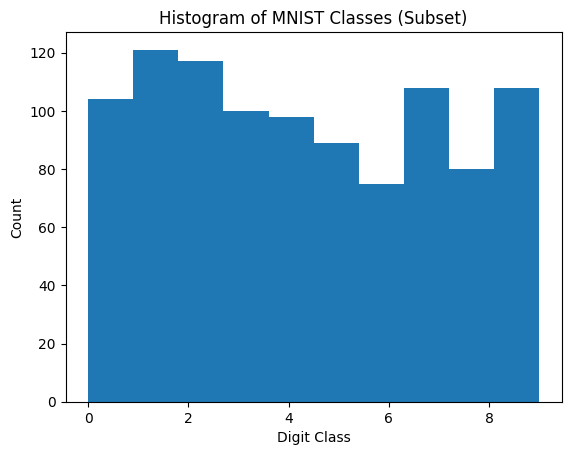

In [ ]:
plt.hist(labels.numpy(), bins=10)
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.title("Histogram of MNIST Classes (Subset)")
plt.show()
# here this is plotting a histogram that shows the distribution of classes in the subset.

Using the einops python package to "batch" the subset of MNIST images. Each batch should contain 25 different samples.

In [ ]:
batchedImages = rearrange(images, "(b n) c h w -> b n c h w", n = 25)
print(batchedImages.shape)
# in this part, i reshaped the dataset into batches of 25 samples (using einops). the result is [40, 25, 1, 28, 28].

torch.Size([40, 25, 1, 28, 28])


Pick a random image.

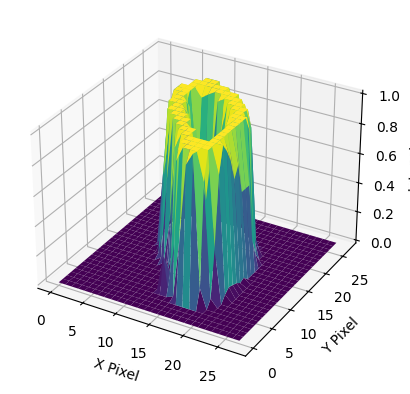

In [ ]:
idx = np.random.randint(0,1000)
img = images[idx][0].numpy()

x = np.arange(28)
y = np.arange(28)
x, y = np.meshgrid(x, y)

fig = plt.figure()
ax = fig.add_subplot(111, projection = "3d")
ax.plot_surface(x, y, img, cmap = "viridis")

ax.set_xlabel("X Pixel")
ax.set_ylabel("Y Pixel")
ax.set_zlabel("Intensity")

plt.show()
# picked a random digit and plotted its pixel intensities (z axis). the x and y axes are the pixel positions.


Next task is  to load the data (energydata complete.csv) and perform some different analysis.

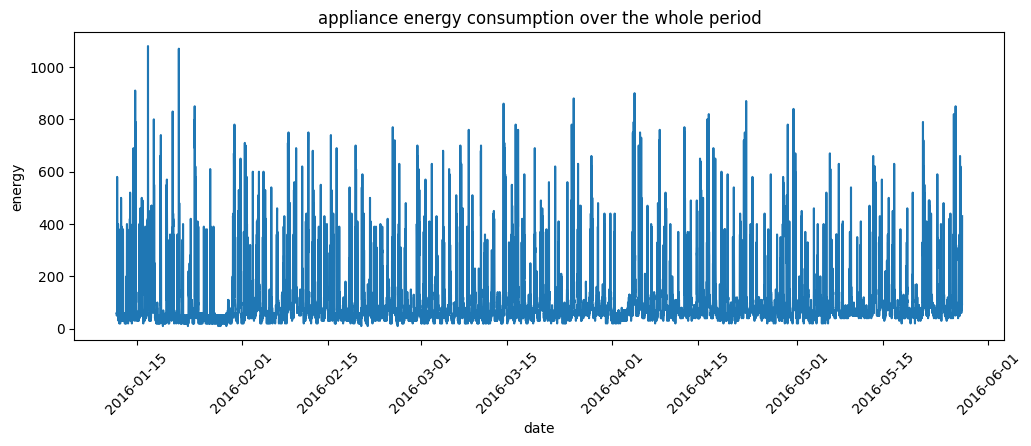

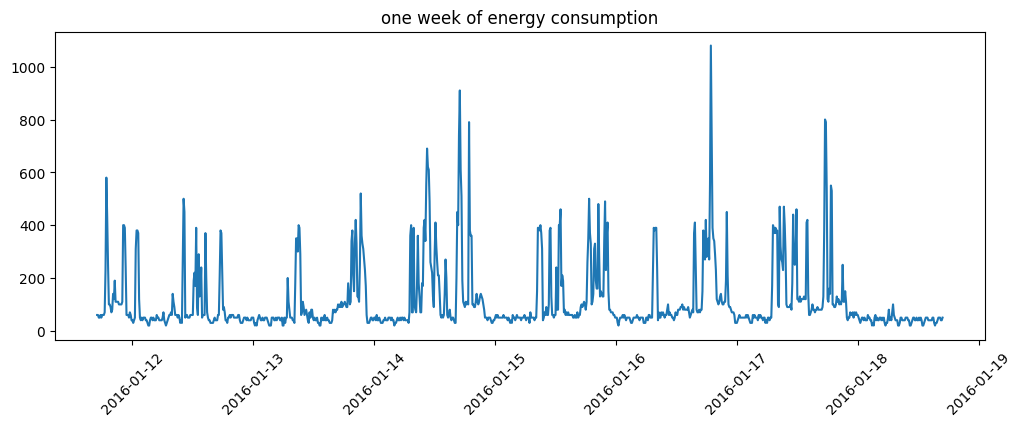

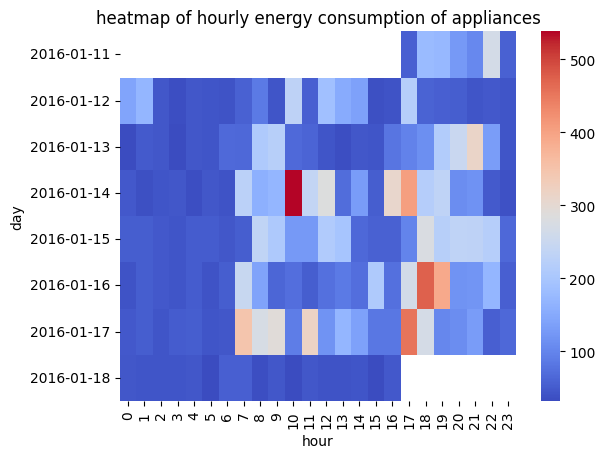

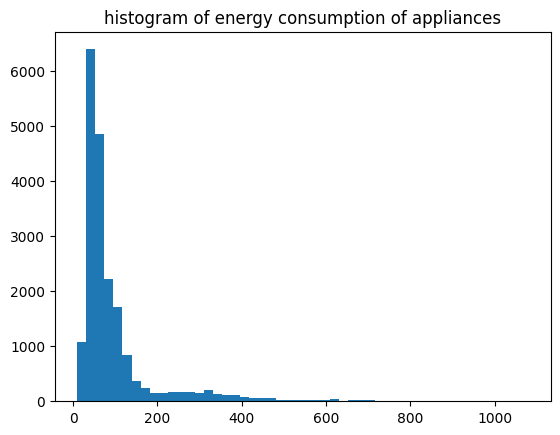

In [ ]:
df = pd.read_csv("energydata_complete.csv")
df.head()

df["date"] = pd.to_datetime(df["date"])
df["appliances"] = pd.to_numeric(df["Appliances"])

plt.figure(figsize = (12,4))
plt.plot(df["date"], df["Appliances"])
plt.title("appliance energy consumption over the whole period")
plt.xticks(rotation=45)
plt.xlabel("date")
plt.ylabel("energy")
plt.show()

# here we are plotting the appliances' energy consumption over the entire period.

week_data = df.iloc[:7*24*6] # There are 7 days in a week, 24 hours in a day, and 6 samples per hour (from frequency of one sample per 10 minutes)

plt.figure(figsize = (12,4))
plt.plot(week_data["date"], week_data["appliances"])
plt.title("one week of energy consumption")
plt.xticks(rotation=45)
plt.show()

# this is one week of energy consumption

# hourly consumption
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.date

week = df.iloc[:7*24*6]

pivot = week.pivot_table(values = "Appliances", index = "day", columns = "hour", aggfunc = "mean")
sns.heatmap(pivot, cmap = "coolwarm")
plt.title("heatmap of hourly energy consumption of appliances")
plt.show()
# i used a pivot table and heatmap to get a look at the average hourly energy consumption of appliances for each day of the week.

plt.hist(df["appliances"], bins = 50)
plt.title("histogram of energy consumption of appliances")
plt.show()
# histogram shows how energy consumption values are distributed. you can easily see skewness or outliers.

Construct a feature variable NSM (no. of seconds from midnight) and plot energy
consumption vs. NSM.

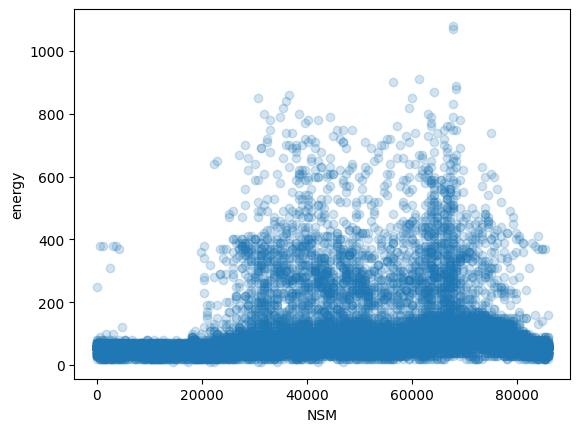

In [ ]:
df["NSM"] = (df["date"].dt.hour * 3600 + df["date"].dt.minute * 60 + df["date"].dt.second)
plt.scatter(df["NSM"], df["appliances"], alpha = 0.2)
plt.xlabel("NSM")
plt.ylabel("energy")
plt.show()
# create NSM as a feature so we can analyze time-based patterns.
# there is an output of a scatter plot.

Plot appliances energy consumption vs. Press mm Hg.

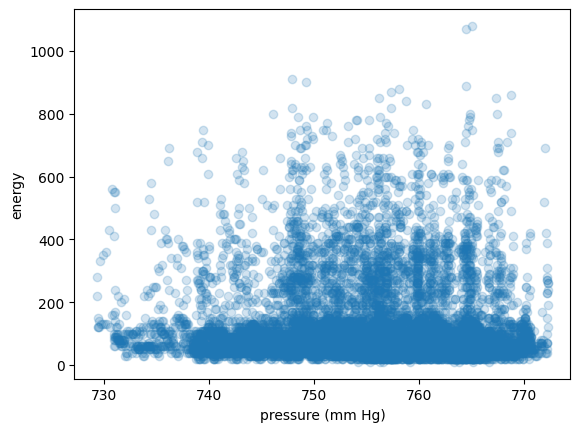

In [ ]:
plt.scatter(df["Press_mm_hg"], df["Appliances"], alpha = 0.2)
plt.xlabel("pressure (mm Hg)")
plt.ylabel("energy")
plt.show()

Load the data and Compute the following descriptive statistics of the data: Mean, Variance (or Standard Deviation), Median, Kurtosis, Skewness, and Range.

In [ ]:
df_airfoil = pd.read_csv("airfoil_self_noise.dat", delim_whitespace = True, header = None)
df_airfoil.columns = ['frequency', 'angle', 'chord', 'velocity', 'thickness', 'sound']

df_airfoil.describe()

print("mean: ", df_airfoil.mean())
print("variance: ", df_airfoil.var())
print("median: ", df_airfoil.median())
print("kurtosis: ", df_airfoil.kurtosis())
print("skewness: ", df_airfoil.skew())
print("range: ", df_airfoil.max() - df_airfoil.min())

# here it is computing descriptive statistics and printing them out.

mean:  frequency    2886.380572
angle           6.782302
chord           0.136548
velocity       50.860745
thickness       0.011140
sound         124.835943
dtype: float64
variance:  frequency    9.938717e+06
angle        3.502424e+01
chord        8.749868e-03
velocity     2.425116e+02
thickness    1.729287e-04
sound        4.759146e+01
dtype: float64
median:  frequency    1600.000000
angle           5.400000
chord           0.101600
velocity       39.600000
thickness       0.004957
sound         125.721000
dtype: float64
kurtosis:  frequency    5.708685
angle       -0.412951
chord       -1.037964
velocity    -1.563951
thickness    2.218903
sound       -0.314187
dtype: float64
skewness:  frequency    2.137084
angle        0.689164
chord        0.457457
velocity     0.235852
thickness    1.702165
sound       -0.418952
dtype: float64
range:  frequency    19800.000000
angle           22.200000
chord            0.279400
velocity        39.600000
thickness        0.058011
sound           37

/tmp/ipython-input-235/3631596800.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_airfoil = pd.read_csv("airfoil_self_noise.dat", delim_whitespace = True, header = None)


Write code to randomly rotate, shift, scale, and warp the image of the patches.
Thus, generate 100 images.

Obtain local patches (of a certain fixed size of your choice, much smaller than the
original image size) from all the leaf images.

In [ ]:
transformAug = T.Compose([T.RandomRotation(30), T.RandomResizedCrop(size = 128), T.RandomAffine(degrees = 0, translate = (0.1, 0.1))])

# this line applies random rotation, crops randomly, and shifts randomly to create different variations of the images.

augmentedImages = []
files = ["I1.png","I2.png","I3.png","I4.png","I5.png","I6.png","I7.png","I8.png"]
for n in range (8):
  for i in range (100):
      img = Image.open(files[n])
      aug = transformAug(img)
      augmentedImages.append(aug)
# this generates 100 augmented images per original image. this increases the data diversity for better model training.

In [ ]:
patch_size = 16
patches = []

def extract_patches(img, patch_size, n_patches=200):

    h, w, c = img.shape
    local_patches = []

    for _ in range(n_patches):

        x = np.random.randint(0, w - patch_size)
        y = np.random.randint(0, h - patch_size)

        patch = img[y:y+patch_size, x:x+patch_size]
        local_patches.append(patch)

    return local_patches

# randomly it samples small patches from each augmented image to focus on local features.

for img in augmentedImages:
    # Ensure float format
    if isinstance(img, Image.Image):
      img = np.array(img)

    img = img.astype(np.float32) / 255.0

    patches = extract_patches(img, patch_size)
    patches.extend(patches)

patches = np.array(patches)

print("Patch shape:", patches.shape)
print("Data type:", patches.dtype)
print("Min value:", patches.min())
print("Max value:", patches.max())

Patch shape: (400, 16, 16, 4)
Data type: float32
Min value: 0.0
Max value: 1.0


whitening

In [ ]:
def zca_whitening_matrix(X, epsilon = 1e-5):
  # torch.mm multiplies the input and matrix and outputs a tensor.
  cov = torch.mm(X.t(), X) / X.size(0)
  U, S, _ = torch.linalg.svd(cov)
  w = torch.mm(torch.mm(U, torch.diag(1.0 / torch.sqrt(S + epsilon))), U.t())
  return w
# this part calculates the covariance matrix, then uses SVD to compute the whitening matrix, which decorrelates the data.

def zca_whitening(X, epsilon = 1e-5):
  w = zca_whitening_matrix(X, epsilon)
  X_zca = torch.mm(X, w)
  return X_zca


patches = patches.float()
n, c, h, w = patches.shape
X = patches.view(n, -1)
X = X - X.mean(dim=0, keepdim=True)
X_zca = zca_whitening(X)
whitened_images = X_zca.view(n, c, h, w)

# centers the data by subtracting the mean before applying the whitening, which is necessary and important.

In [ ]:
def channel_distribution(tensor):
    n, c, h, w = tensor.shape

    for l in range(c):
        channel = tensor[:, l, :, :].reshape(-1)

        print(f"Channel {l}")
        print("Mean:", channel.mean().item())
        print("Std:", channel.std().item())
        print("Min:", channel.min().item())
        print("Max:", channel.max().item())
        print()
# this is calculatin the mean, standard deviation, minimum, and maximum for each channel to compare the differences between the original and the whitened versions.

print("original: ")
channel_distribution(images)

print("whitened: ")
channel_distribution(whitened_images)

original: 
Channel 0
Mean: 0.13135184347629547
Std: 0.3091059923171997
Min: 0.0
Max: 1.0

whitened: 
Channel 0
Mean: 1.667518461090367e-07
Std: 0.4795980155467987
Min: -2.988814353942871
Max: 2.6272404193878174

Channel 1
Mean: -8.364440695629582e-09
Std: 0.42934760451316833
Min: -2.7980003356933594
Max: 2.6623449325561523

Channel 2
Mean: 3.1951844903232995e-07
Std: 0.41435039043426514
Min: -2.7981414794921875
Max: 1.9788249731063843

Channel 3
Mean: 3.192480733105185e-07
Std: 0.41683509945869446
Min: -2.7979087829589844
Max: 2.268904209136963

Channel 4
Mean: -4.2826985691135633e-07
Std: 0.41718465089797974
Min: -2.7978363037109375
Max: 2.6358964443206787

Channel 5
Mean: -8.533010031896993e-08
Std: 0.41409364342689514
Min: -2.7979583740234375
Max: 2.0142228603363037

Channel 6
Mean: -3.772723857764504e-07
Std: 0.41667672991752625
Min: -2.7979354858398438
Max: 1.9744852781295776

Channel 7
Mean: 5.297837333273492e-07
Std: 0.41552722454071045
Min: -2.798023223876953
Max: 1.92135596275

In [ ]:
image_files = ["1.JPG", "2.JPG", "3.JPG", "4.JPG", "5.JPG"]

def extract_subplots(img):
    original = img.copy()

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    lower_green = np.array([30, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)
# this is going to convert to HSV color space and threshold to isolate green soybean plants.


    kernel = np.ones((15,15), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    # using the cv2.MORPH_CLOSE and cv2.MORPH_OPEN, it removed the "noise" and filled in those gaps in it.

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    boxes = []
    for i in range(1, num_labels):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        area = stats[i, cv2.CC_STAT_AREA]
        if area > 15000:
            boxes.append((x, y, w, h))
    # this part detects connected parts that represent the subplots. it filters by area to remove small "noise"

    boxes = sorted(boxes, key=lambda b: (b[1], b[0]))
    # this is sorting the boxes by their vertical position, then by their horizontal position.
    rows = []
    current_row = []
    threshold = 50
    for box in boxes:
        if not current_row:
            current_row.append(box)
        elif abs(box[1] - current_row[0][1]) < threshold:
            current_row.append(box)
        else:
            rows.append(sorted(current_row, key=lambda b: b[0]))
            current_row = [box]
    if current_row:
        rows.append(sorted(current_row, key=lambda b: b[0]))

    ordered_boxes = [b for row in rows for b in row]

    for idx, (x, y, w, h) in enumerate(ordered_boxes):
        cv2.rectangle(original, (x, y), (x + w, y + h), (0, 0, 255), 2)
        cv2.putText(original, str(idx + 1), (x + 5, y + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    subplots = [img[y:y+h, x:x+w] for x, y, w, h in ordered_boxes]
# this is drawing red boxes and labeling each subplot with its corresponding number on each image.

    return original, ordered_boxes, subplots

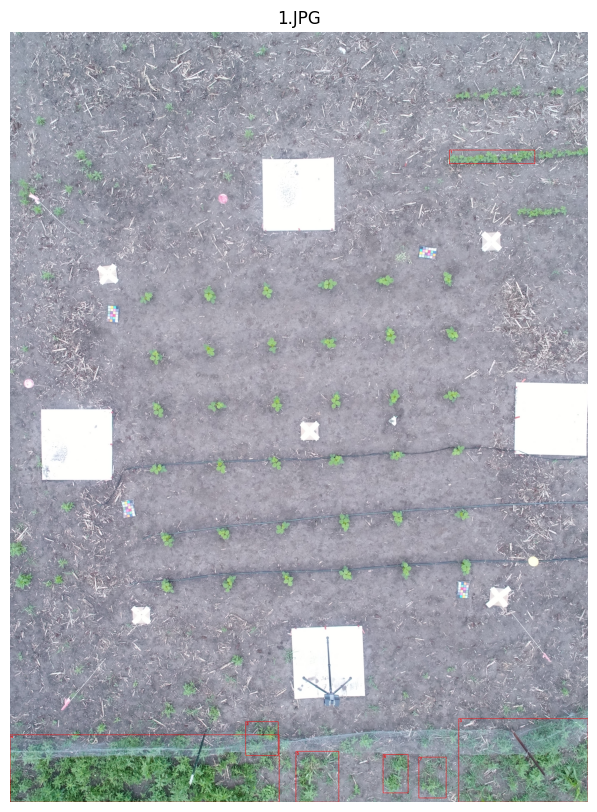

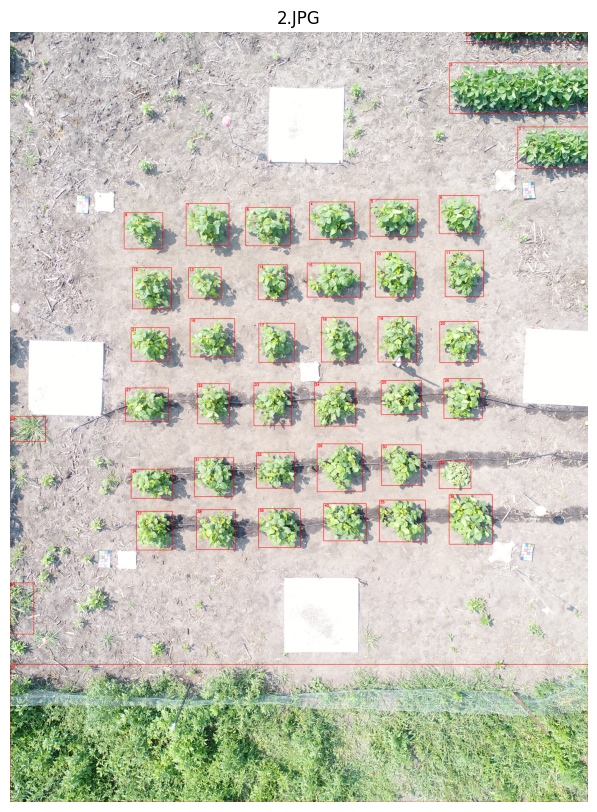

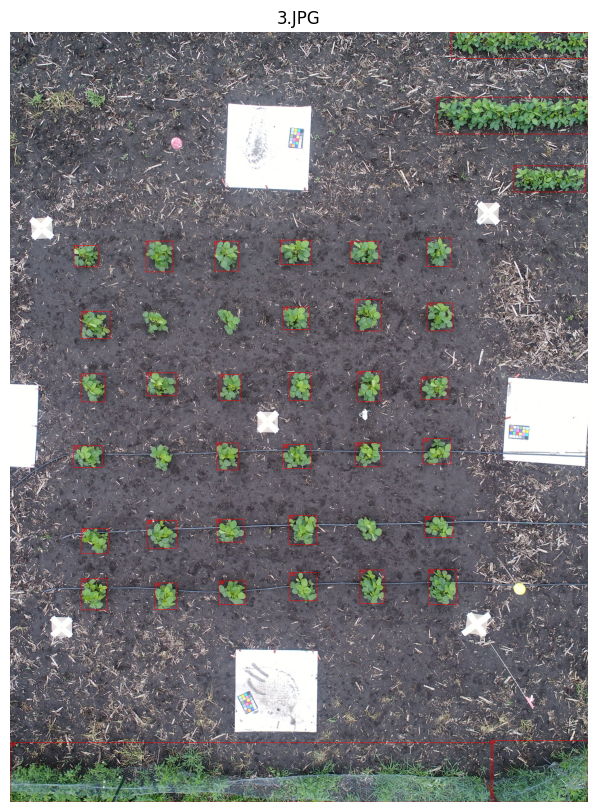

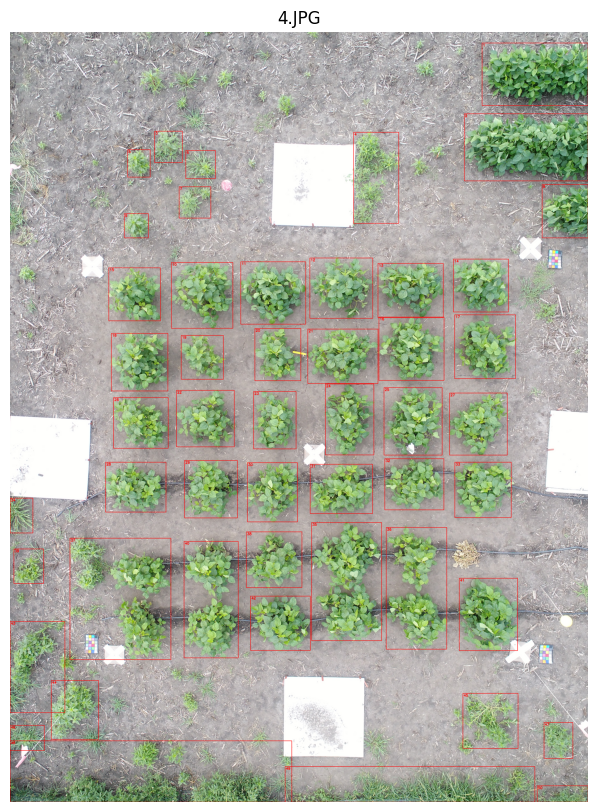

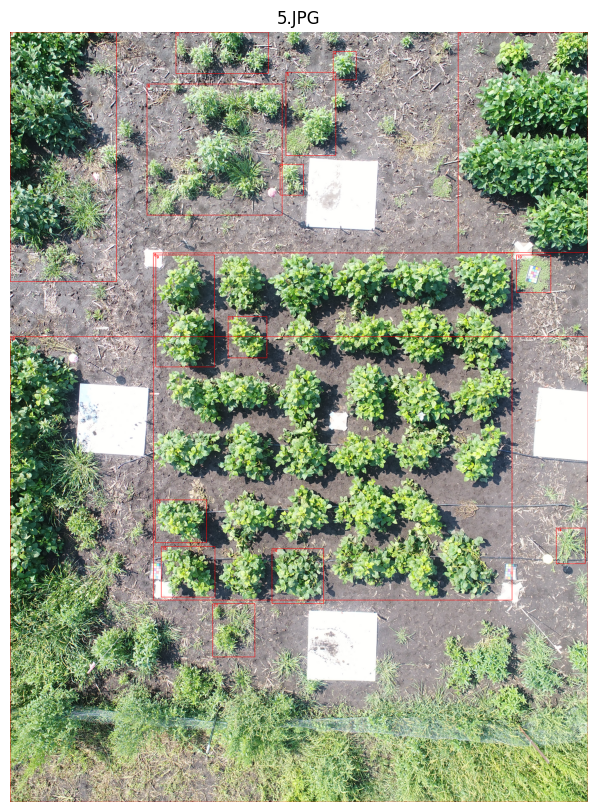

In [ ]:
for file_name in image_files:
    img = cv2.imread(file_name)
    processed_img, boxes, subplots = extract_subplots(img)

    processed_img_rgb = cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,10))
    plt.imshow(processed_img_rgb)
    plt.title(file_name)
    plt.axis('off')
    plt.show()

    # finally, this displays the image with the boxs and subplot numbers.